<a href="https://colab.research.google.com/github/Amal-Joshy-T/ML-and-DL-Projects/blob/main/Student%20Performace/Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**
Project title
AI Based Student Performance Prediction System

Problem statement
Educational institutions struggle to identify students who are at risk of poor academic performance early. This project predicts student performance using historical academic and behavioural data to support timely intervention.

Objective
To build a machine learning model that predicts whether a student will perform well or poorly based on multiple factors and provide insights for improvement.

Dataset
Student academic dataset containing
Attendance percentage
Internal assessment marks
Previous semester grades
Study hours
Participation in activities
Socio economic indicators
You can use a public dataset or create a realistic one.

Technologies used
Python
Pandas
NumPy
Matplotlib and Seaborn
Scikit learn
Jupyter Notebook.

Workflow
1 Data understanding and problem definition
2 Data cleaning and handling missing values
3 Exploratory data analysis
4 Feature selection and encoding
5 Train test split
6 Model building using Logistic Regression Random Forest
7 Model evaluation using accuracy precision recall and confusion matrix
8 Result interpretation and insights
9 Conclusion and future scope.

Output
Prediction of student performance category
Important features influencing performance
Visual dashboards showing trends


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/student_performance_2_lakh_rows.csv')
df.head()

,attendance_percentage,internal_marks,previous_sem_grade,study_hours_per_day,activity_participation,socio_economic_score,student_performance
0,79.967142,88.427611,2,3.664112,1,5.376612,Good
1,73.617357,63.586575,2,1.890889,1,6.434583,Poor
2,81.476885,45.056966,2,3.811742,0,6.943090,Poor
3,90.230299,44.170428,1,2.004269,1,3.763248,Poor
4,72.658466,59.860238,4,2.456520,0,10.000000,Good


In [ ]:
df.isnull().sum()

,0
attendance_percentage,0
internal_marks,0
previous_sem_grade,0
study_hours_per_day,0
activity_participation,0
socio_economic_score,0
student_performance,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   attendance_percentage   200000 non-null  float64
 1   internal_marks          200000 non-null  float64
 2   previous_sem_grade      200000 non-null  int64  
 3   study_hours_per_day     200000 non-null  float64
 4   activity_participation  200000 non-null  int64  
 5   socio_economic_score    200000 non-null  float64
 6   student_performance     200000 non-null  object 
dtypes: float64(4), int64(2), object(1)
memory usage: 10.7+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

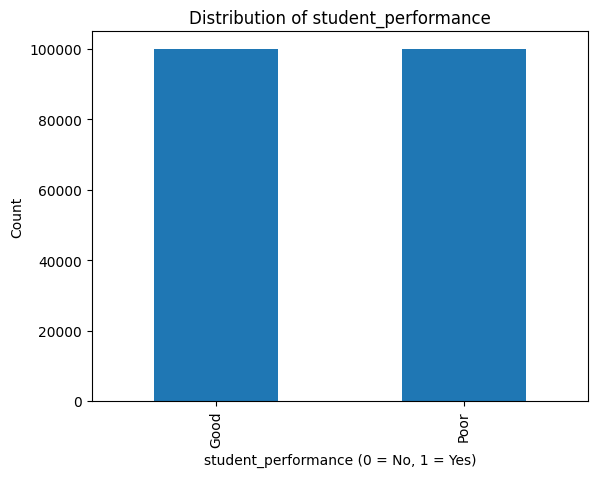

In [ ]:
plt.figure()
df['student_performance'].value_counts().plot(kind='bar')
plt.xlabel('student_performance (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.title('Distribution of student_performance')
plt.show()

<Axes: xlabel='attendance_percentage', ylabel='Count'>

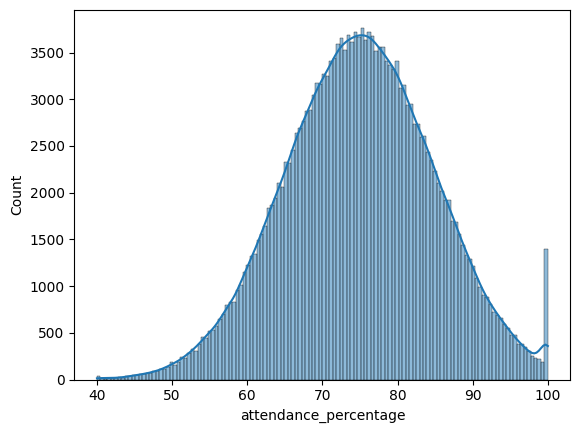

In [ ]:
sns.histplot(df['attendance_percentage'], kde=True)


<Axes: xlabel='internal_marks', ylabel='Count'>

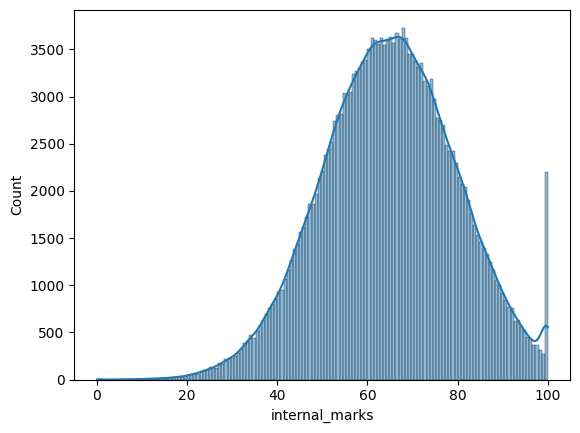

In [ ]:
sns.histplot(df['internal_marks'], kde=True)


<Axes: xlabel='study_hours_per_day', ylabel='Count'>

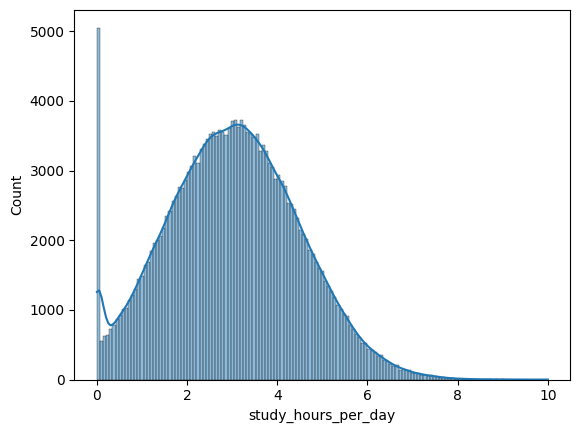

In [ ]:
sns.histplot(df['study_hours_per_day'], kde=True)


<Axes: xlabel='student_performance', ylabel='attendance_percentage'>

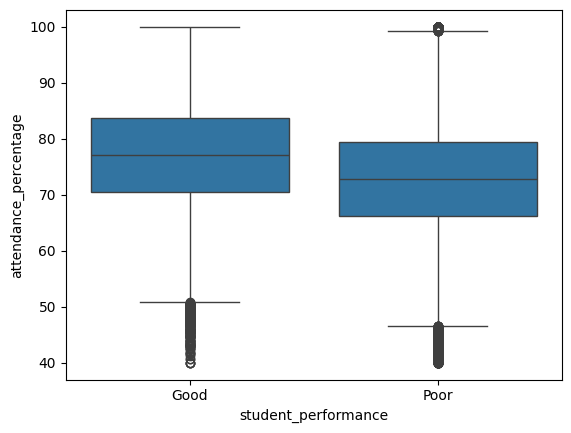

In [ ]:
sns.boxplot(x='student_performance', y='attendance_percentage', data=df)


<Axes: xlabel='student_performance', ylabel='internal_marks'>

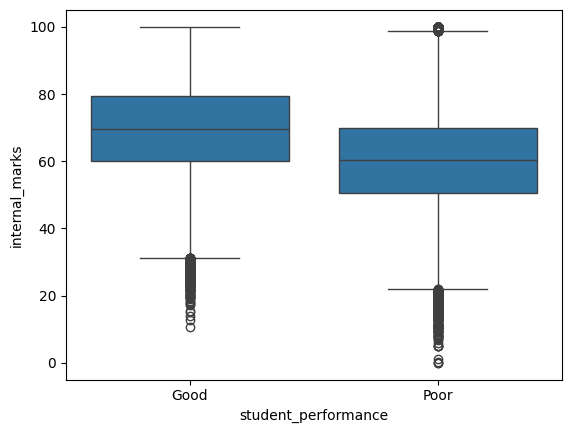

In [ ]:
sns.boxplot(x='student_performance', y='internal_marks', data=df)


<Axes: xlabel='student_performance', ylabel='study_hours_per_day'>

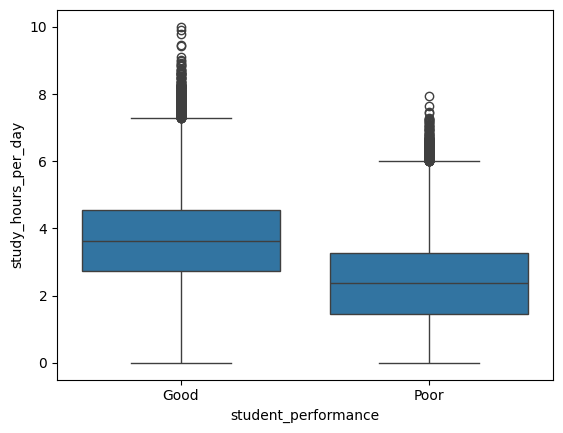

In [ ]:
sns.boxplot(x='student_performance', y='study_hours_per_day', data=df)


<Axes: xlabel='activity_participation', ylabel='count'>

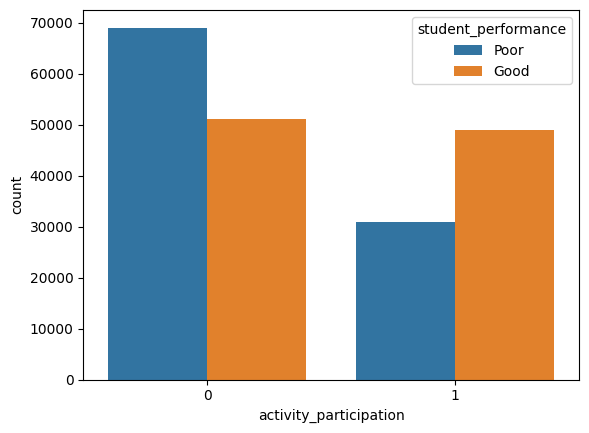

In [ ]:
sns.countplot(x='activity_participation', hue='student_performance', data=df)


<Axes: xlabel='previous_sem_grade', ylabel='count'>

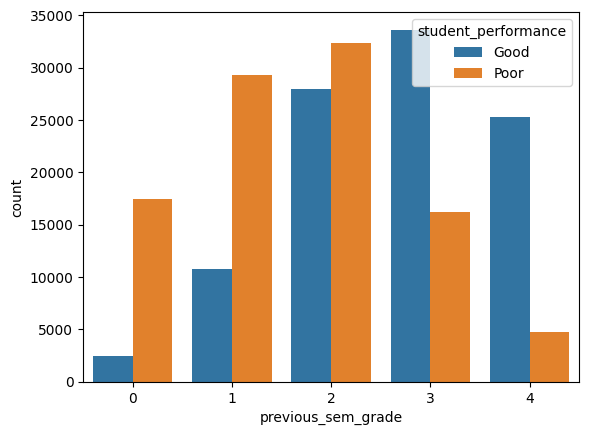

In [ ]:
sns.countplot(x='previous_sem_grade', hue='student_performance', data=df)


In [ ]:
df['student_performance'].unique()

array(['Good', 'Poor'], dtype=object)

In [ ]:
df['student_performance'].replace({'Good':1,'Poor':0},inplace=True)

/tmp/ipython-input-3869142430.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['student_performance'].replace({'Good':1,'Poor':0},inplace=True)
/tmp/ipython-input-3869142430.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['student_performance'].replace({'Good':1,'Poor':0},inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   attendance_percentage   200000 non-null  float64
 1   internal_marks          200000 non-null  float64
 2   previous_sem_grade      200000 non-null  int64  
 3   study_hours_per_day     200000 non-null  float64
 4   activity_participation  200000 non-null  int64  
 5   socio_economic_score    200000 non-null  float64
 6   student_performance     200000 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 10.7 MB


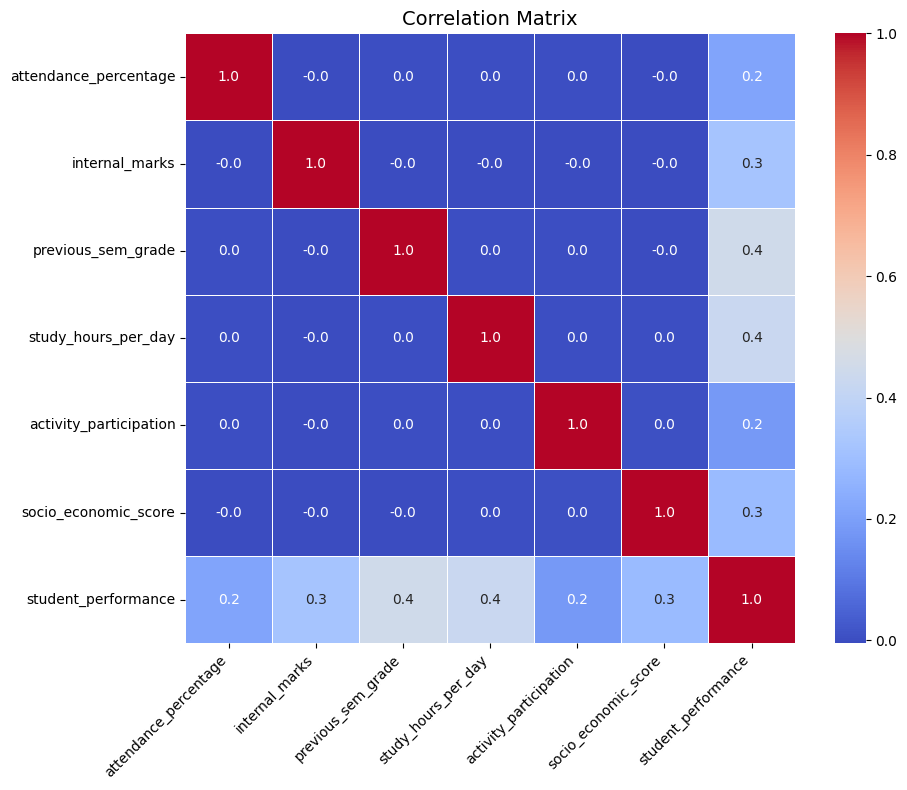

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".01f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Matrix", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

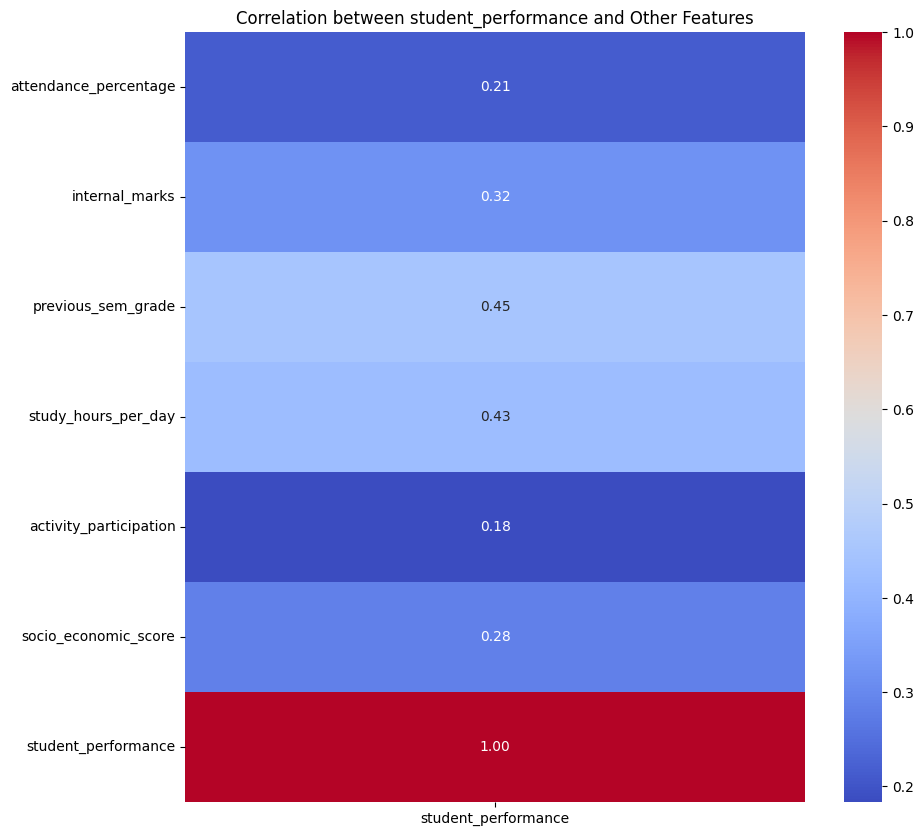

In [ ]:
student_performance_corr = df.corr()['student_performance']


HadHeartAttack_corr = student_performance_corr.drop('student_performance')
plt.figure(figsize=(10, 10))
sns.heatmap(student_performance_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation between student_performance and Other Features')

plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   attendance_percentage   200000 non-null  float64
 1   internal_marks          200000 non-null  float64
 2   previous_sem_grade      200000 non-null  int64  
 3   study_hours_per_day     200000 non-null  float64
 4   activity_participation  200000 non-null  int64  
 5   socio_economic_score    200000 non-null  float64
 6   student_performance     200000 non-null  int64  
dtypes: float64(4), int64(3)
memory usage: 10.7 MB


<Axes: >

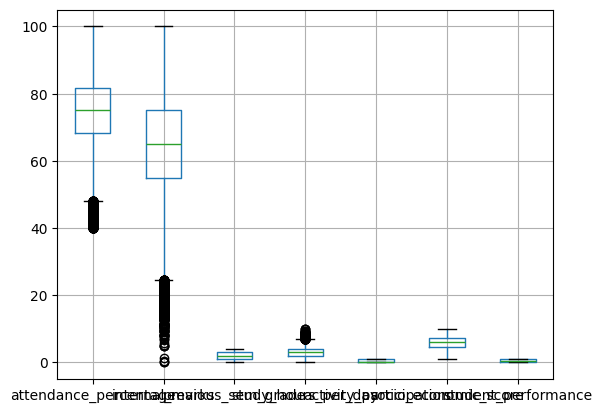

In [ ]:
df.boxplot()

In [ ]:

def remove_outliers_iqr(df, exclude_column):
    for col in df.columns:

        if col == exclude_column:
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

df_cleaned = remove_outliers_iqr(df, exclude_column='student_performance')
df=df_cleaned

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.preprocessing import StandardScaler


In [ ]:

X = df.drop('student_performance', axis=1)
y = df['student_performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')


Baseline model accuracy: 1.00


In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.94


In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=5000,
    random_state=42
)

svclassifier.fit(X_train_scaled, y_train)
svclassifier.score(X_test_scaled, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.9988678406081314

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model =RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.98


In [ ]:
from sklearn.model_selection import KFold
kf=KFold(n_splits=8,shuffle=True,random_state=42)
model=LogisticRegression()

In [ ]:
best_accuracy = 0
best_fold = -1
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 1 Accuracy: 0.9990295972828724


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 2 Accuracy: 0.9990295972828724
Fold 3 Accuracy: 0.9995552320879831
Fold 4 Accuracy: 0.9997169544296631
Fold 5 Accuracy: 0.9997978245926166
Fold 6 Accuracy: 0.9993934737778497


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Fold 7 Accuracy: 0.9973312846225385
Fold 8 Accuracy: 0.9995552141037565

 Best Fold: 5 with Accuracy: 0.9997978245926166


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9997978245926166

In [ ]:
model=DecisionTreeClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9460191662286199

In [ ]:
model=RandomForestClassifier()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9764263474990902

In [ ]:
from sklearn.svm import SVC

svclassifier = SVC(
    kernel="linear",
    cache_size=2000,
    max_iter=5000,
    random_state=42
)

svclassifier.fit(best_X_train,best_y_train)
svclassifier.score(best_X_test,best_y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


0.9710889167441672

# **DL**

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
best_X_train,best_X_test,best_y_train,best_y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=42)

In [ ]:
model=Sequential()
model.add(Dense(128,input_shape=(best_X_train.shape[1],),activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
model.fit(best_X_train,best_y_train,epochs=60,batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.9789 - loss: 0.0595
Epoch 2/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.9936 - loss: 0.0150
Epoch 3/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9948 - loss: 0.0121
Epoch 4/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - accuracy: 0.9955 - loss: 0.0105
Epoch 5/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9959 - loss: 0.0096
Epoch 6/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9959 - loss: 0.0097
Epoch 7/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9965 - loss: 0.0083
Epoch 8/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.9963 - loss: 0.0082
Epoch 9/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9965 - loss: 0.0080
Epoch 10/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9964 - loss: 0.0085
Epoch 11/60
4328/4328 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9965 - loss: 0.0079
Epoch 12/60
4328/43

In [ ]:
loss,accuracy=model.evaluate(best_X_test,best_y_test)
print(f'model accuracy:{accuracy*100:.2f}%')

1855/1855 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9975 - loss: 0.0058
model accuracy:99.76%


In [ ]:
best_X_test

array([[ 1.68606633, -0.20332187, -0.96518363,  0.03734531,  1.22688053,
        -1.82022027],
       [ 0.87308344, -0.11510421,  0.71092621, -1.63446599, -0.81507529,
         0.41398945],
       [ 0.19654734, -0.15110578, -0.96518363,  0.03739112, -0.81507529,
        -0.0446529 ],
       ...,
       [ 0.60995025,  0.96672092,  1.54898113, -1.82786631,  1.22688053,
         0.4617374 ],
       [ 1.00491647, -1.38469107, -0.12712871,  0.62177153, -0.81507529,
         0.23431231],
       [ 0.81194755, -0.97891476, -0.12712871, -0.01867954,  1.22688053,
         0.62264396]])

In [ ]:
best_y_test

,student_performance
76230,0
108732,0
122359,0
54492,0
141489,0
...,...
168480,0
124402,1
31017,1
183577,0


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.9995619650919874

In [ ]:
import pickle
with open("Student Performance Logisticmodel.pkl","wb") as file:
  pickle.dump(model,file)

In [ ]:
with open("/content/Student Performance Logisticmodel.pkl","rb") as file:
  load_model=pickle.load(file)

In [ ]:
load_model.predict([[ 1.68606633, -0.20332187, -0.96518363,  0.03734531,  1.22688053,
        -1.82022027]])

array([0])

In [ ]:
load_model.predict([ [ 0.81194755, -0.97891476, -0.12712871, -0.01867954,  1.22688053,
         0.62264396]])

array([1])

# **Conclusion**

This project successfully developed an AI-based system to predict student performance using academic and behavioral data. Machine learning and deep learning models were trained with proper preprocessing and feature scaling. The results show that factors such as attendance, internal marks, study hours, and previous performance strongly influence student outcomes. The system can help institutions identify at-risk students early and support timely academic interventions.